# Rich output and build progress

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/xavierforge/colab-rust/blob/main/examples/02_rich_output.ipynb)

What `%%rust` cells give you beyond text. Run the setup cell first, then each section stands on its own.


In [1]:
!curl -fsSL -o setup.sh https://raw.githubusercontent.com/xavierforge/colab-rust/main/setup.sh
!bash setup.sh
%load_ext colab_rust

▶ colab-rust setup (ref: main)
▶ Installing Rust (stable, minimal profile)...
✅ Rust 1.98.1
▶ Attempting prebuilt evcxr_jupyter download...
✅ Installed prebuilt evcxr_jupyter
✅ evcxr_jupyter at /root/.cargo/bin/evcxr_jupyter
✅ Rust kernel registered with Jupyter
▶ Installing colab_rust.py magic module...
✅ colab_rust.py 0.1.4 ready at /content/colab_rust.py (ref: main)

🎉 Setup complete.

Next steps in your notebook:

    %load_ext colab_rust

    %%rust
    println!("Hello from Rust on Colab!");

For compile-heavy crates (candle, tch), prefer a Cargo project
with !cargo run over :dep. See examples/ for patterns.
✅ colab_rust 0.1.4 loaded — use %%rust in any cell


## Build progress

The first `:dep` compiles the crate. Watch the line under the cell while it runs. It names the crate cargo is on and how long it has been going, then collapses to a one-line summary when the build is done.


In [2]:
%%rust
:dep image = "0.23"
:dep evcxr_image = "1.1"
println!("image crate ready");

   Compiled 22 crates in 59s

image crate ready


## Images

Anything evcxr can display, Colab now renders. `evcxr_image` turns an `ImageBuffer` into a PNG.


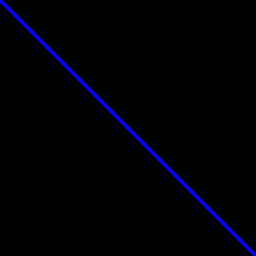

In [3]:
%%rust
use evcxr_image::ImageDisplay;

image::ImageBuffer::from_fn(256, 256, |x, y| {
    if (x as i32 - y as i32).abs() < 3 {
        image::Rgb([0, 0, 255])
    } else {
        image::Rgb([0, 0, 0])
    }
})

## HTML

A type that implements `evcxr_display` can emit HTML. This one renders a matrix as a table.


In [4]:
%%rust
use std::fmt::Debug;

pub struct Matrix<T> { pub values: Vec<T>, pub row_size: usize }

impl<T: Debug> Matrix<T> {
    pub fn evcxr_display(&self) {
        let mut html = String::from("<table>");
        for row in self.values.chunks(self.row_size) {
            html.push_str("<tr>");
            for v in row {
                html.push_str(&format!("<td>{v:?}</td>"));
            }
            html.push_str("</tr>");
        }
        html.push_str("</table>");
        println!("EVCXR_BEGIN_CONTENT text/html\n{html}\nEVCXR_END_CONTENT");
    }
}

let m = Matrix { values: vec![1, 2, 3, 4, 5, 6, 7, 8, 9], row_size: 3 };
m

1,2,3
4,5,6
7,8,9


## stdout and stderr

The two streams stay apart, so `eprintln!` and compiler errors show up the way Colab shows any stderr.


In [5]:
%%rust
println!("this goes to stdout");
eprintln!("this goes to stderr");

this goes to stdout


this goes to stderr


In [6]:
%%rust
let n: i32 = "not a number";

[E0308] Error: mismatched types
   ╭─[ command_6:1:1 ]
   │
 1 │ let n: i32 = "not a number";
   │        ─┬─   ───────┬──────  
   │         ╰──────────────────── expected due to this
   │                     │        
   │                     ╰──────── expected `i32`, found `&str`
───╯


## Interrupting

Run the loop below and press the stop button after a few seconds. The loop actually stops, the notebook reports what happened, and the cell after it still works.

What survives an interrupt: items from earlier cells (functions, structs, `:dep` crates), which is why `greet` is defined in its own cell first. What does not: variables, and anything the interrupted cell itself was defining, since evcxr only commits a cell's definitions once it finishes.


In [13]:
%%rust
fn greet() -> &'static str { "still here" }

In [14]:
%%rust
for i in 1.. {
    println!("{i}");
    std::thread::sleep(std::time::Duration::from_secs(1));
}

[colab_rust] interrupt requested; stopping the Rust kernel...
[colab_rust] Interrupted. Variables were reset; items (fn/struct/:dep) are kept.


KeyboardInterrupt: 

In [15]:
%%rust
greet()

"still here"
